In [4]:
!pip install langgraph

  Using cached langgraph-1.2.4-py3-none-any.whl.metadata (8.0 kB)
  Using cached langchain_core-1.4.1-py3-none-any.whl.metadata (4.5 kB)
  Using cached langgraph_checkpoint-4.1.1-py3-none-any.whl.metadata (5.2 kB)
  Using cached langgraph_prebuilt-1.1.0-py3-none-any.whl.metadata (5.2 kB)
  Using cached langgraph_sdk-0.4.2-py3-none-any.whl.metadata (3.6 kB)
  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached jsonpatch-1.33-py2.py3-none-any.whl.metadata (3.0 kB)
  Using cached langchain_protocol-0.0.16-py3-none-any.whl.metadata (2.4 kB)
  Using cached langsmith-0.8.9-py3-none-any.whl.metadata (15 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached jsonpointer-3.1.1-py3-none-any.whl.metadata (2.4 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl.metadata (14 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached anyio-4.13.

In [8]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph                    #framework that helps you design and manage the flow of tasjs in your application using a graph

In [18]:
# we now create an AgentSate - shared data structure that keeps track of information as your application runs

class AgentState(TypedDict):           # Our state Schema
    message : str


def greeting_node(state: AgentState) -> AgentState:
    """Simple node that adds a greeting message to the state"""

    state['message'] = state["message"] + " , you are doing an amazing job learning LangGraph!"

    return state



In [19]:
graph = StateGraph(AgentState)

graph.add_node("greeter",greeting_node)

graph.set_entry_point("greeter")
graph.set_finish_point("greeter")

app=graph.compile()

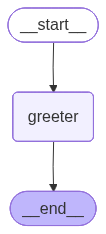

In [15]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [20]:
result = app.invoke({"message":"Bob"})

In [21]:
result["message"]

'Bob , you are doing an amazing job learning LangGraph!'

┌─────────────────────────────────────────────────────────┐
│                     AgentState                          │
│                  { message: str }                       │
└─────────────────────────────────────────────────────────┘

         Input: {"message": "Bob"}
                      │
                      ▼
              ┌───────────────┐
              │   __start__   │
              └───────┬───────┘
                      │
                      ▼
              ┌───────────────┐
              │    greeter    │  ← greeting_node()
              │               │
              │  message +=   │
              │  ", you are   │
              │  doing an     │
              │  amazing job" │
              └───────┬───────┘
                      │
                      ▼
              ┌───────────────┐
              │    __end__    │
              └───────────────┘
                      │
                      ▼
         Output: {"message": "Bob , you are doing
                  an amazing job learning LangGraph!"}

